# Sparse Autoencoders (SAE) sur 10% de MNIST

Ce notebook implémente un autoencodeur sparse qui ajoute une contrainte de sparsité sur les activations latentes.
Contrairement aux autoencodeurs standard (082), le SAE encourage une représentation parcimonieuse via une pénalité KL divergence.
On suit la même logique que les notebooks 082 et 083: données stratifiées, recherche Optuna, entraînement final, évaluation et visualisations.

In [1]:
import sys
import subprocess
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

try:
    import optuna
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "--quiet"])
    import optuna

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Préparation des données

On charge MNIST complet, on extrait 10% stratifié, puis on divise en train/val/test (70% / 15% / 15%).

In [2]:
print("Chargement de MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(int)

X_sample, _, y_sample, _ = train_test_split(
    X,
    y,
    train_size=0.10,
    stratify=y,
    random_state=42,
)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_sample,
    y_sample,
    test_size=0.30,
    stratify=y_sample,
    random_state=42,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42,
)

print(f"X total        : {X.shape}")
print(f"X 10% sample   : {X_sample.shape}")
print(f"Train / Val / Test : {X_train.shape} / {X_val.shape} / {X_test.shape}")
print("Distribution train:", np.bincount(y_train))
print("Distribution val  :", np.bincount(y_val))
print("Distribution test :", np.bincount(y_test))

Chargement de MNIST...
X total        : (70000, 784)
X 10% sample   : (7000, 784)
Train / Val / Test : (4900, 784) / (1050, 784) / (1050, 784)
Distribution train: [483 552 489 500 477 442 482 510 478 487]
Distribution val  : [104 118 105 107 103  94 103 109 102 105]
Distribution test : [103 118 105 107 102  95 103 110 103 104]


## Architecture et fonctions d'entraînement

**Sparse Autoencoder**: encoder → activation latente (sigmoid) → decoder.
La sparsité est imposée via une pénalité KL divergence entre une cible ρ et l'activation moyenne ρ_hat des unités latentes.

In [3]:
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_multiplier=2, activation="relu", latent_activation="sigmoid"):
        super().__init__()
        hidden_dim = latent_dim * hidden_multiplier
        act = self._make_activation(activation)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, latent_dim),
        )
        self.latent_activation = self._make_activation(latent_activation)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def _make_activation(self, activation):
        if activation == "tanh":
            return nn.Tanh()
        if activation == "sigmoid":
            return nn.Sigmoid()
        return nn.ReLU()

    def forward(self, x):
        h = self.encoder(x)
        z = self.latent_activation(h)
        recon = self.decoder(z)
        return recon, z

    def encode(self, x):
        h = self.encoder(x)
        return self.latent_activation(h)


def make_dataloader(X_array, batch_size, shuffle):
    tensor = torch.tensor(X_array, dtype=torch.float32)
    dataset = TensorDataset(tensor, tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False)

In [4]:
def sparsity_kl(rho, rho_hat):
    """KL divergence between target rho and average activation rho_hat."""
    eps = 1e-8
    rho_hat = torch.clamp(rho_hat, eps, 1 - eps)
    term = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
    return torch.sum(term)


def train_sparse_ae(model, train_loader, val_loader, learning_rate, alpha, rho, sparsity_beta, max_epochs, patience=6):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=alpha)
    criterion = nn.MSELoss()
    best_state = None
    best_val = float("inf")
    wait = 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            recon, z = model(xb)
            recon_loss = criterion(recon, yb)
            rho_hat = torch.mean(z, dim=0)
            sparsity_loss = sparsity_kl(torch.tensor(rho, device=device, dtype=z.dtype), rho_hat)
            loss = recon_loss + sparsity_beta * sparsity_loss
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                recon, z = model(xb)
                recon_loss = criterion(recon, yb)
                rho_hat = torch.mean(z, dim=0)
                sparsity_loss = sparsity_kl(torch.tensor(rho, device=device, dtype=z.dtype), rho_hat)
                val_losses.append((recon_loss + sparsity_beta * sparsity_loss).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), best_val

In [5]:
def evaluate_autoencoder(model, X_array, batch_size=256):
    loader = make_dataloader(X_array, batch_size=batch_size, shuffle=False)
    model.eval()
    preds = []
    latents = []
    criterion = nn.MSELoss(reduction="sum")
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            recon, z = model(xb)
            latents.append(z.cpu().numpy())
            preds.append(recon.cpu().numpy())
            total_loss += criterion(recon, yb).item()
    recon_array = np.vstack(preds)
    latent_array = np.vstack(latents)
    mse = total_loss / (len(X_array) * X_array.shape[1])
    return recon_array, latent_array, mse

## Recherche d'hyperparamètres

On utilise Optuna pour explorer: latent_dim, hidden_multiplier, activation, alpha, learning_rate,
batch_size, **rho** (cible de sparsité), **sparsity_beta** (poids de la pénalité KL).

In [6]:
def objective(trial):
    latent_dim = trial.suggest_categorical("latent_dim", [8, 16, 32, 64])
    hidden_multiplier = trial.suggest_categorical("hidden_multiplier", [2, 3])
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    alpha = trial.suggest_float("alpha", 1e-6, 1e-3, log=True)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    rho = trial.suggest_float("rho", 0.01, 0.2)
    sparsity_beta = trial.suggest_float("sparsity_beta", 1e-3, 1.0, log=True)
    max_epochs = trial.suggest_int("max_epochs", 20, 40, step=10)

    model = SparseAutoencoder(
        input_dim=X_train.shape[1],
        latent_dim=latent_dim,
        hidden_multiplier=hidden_multiplier,
        activation=activation,
        latent_activation="sigmoid",
    ).to(device)

    train_loader = make_dataloader(X_train, batch_size=batch_size, shuffle=True)
    val_loader = make_dataloader(X_val, batch_size=batch_size, shuffle=False)

    try:
        started_at = time.time()
        trained_model, history, best_val = train_sparse_ae(
            model,
            train_loader,
            val_loader,
            learning_rate=learning_rate,
            alpha=alpha,
            rho=rho,
            sparsity_beta=sparsity_beta,
            max_epochs=max_epochs,
            patience=6,
        )
        trial.set_user_attr("fit_time", time.time() - started_at)
        trial.set_user_attr("hidden_dim", latent_dim * hidden_multiplier)
        trial.set_user_attr("epochs", int(history["epoch"].iloc[-1]))
        return best_val
    except Exception as error:
        trial.set_user_attr("error", str(error))
        return float("inf")

In [7]:
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=12, show_progress_bar=False)

best_params = study.best_trial.params
best_params["hidden_dim"] = best_params["latent_dim"] * best_params["hidden_multiplier"]

print("Meilleurs hyperparamètres :")
print(best_params)
print(f"Meilleure loss de validation : {study.best_value:.6f}")

trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
trials_df = trials_df.sort_values("value")
trials_df.head(5)

[I 2026-05-08 17:59:15,316] A new study created in memory with name: no-name-e7259be9-c79d-4d28-a66d-5f4cde4eadd6
[I 2026-05-08 17:59:29,126] Trial 0 finished with value: 0.06921294331550598 and parameters: {'latent_dim': 16, 'hidden_multiplier': 2, 'activation': 'tanh', 'alpha': 6.358358856676247e-05, 'learning_rate': 0.0011114989443094978, 'batch_size': 128, 'rho': 0.05034443102887247, 'sparsity_beta': 0.0035113563139704067, 'max_epochs': 20}. Best is trial 0 with value: 0.06921294331550598.
[I 2026-05-08 17:59:35,838] Trial 1 finished with value: 0.0697595939040184 and parameters: {'latent_dim': 16, 'hidden_multiplier': 2, 'activation': 'tanh', 'alpha': 2.334586407601622e-05, 'learning_rate': 0.0014447746112718689, 'batch_size': 256, 'rho': 0.01882557841679957, 'sparsity_beta': 0.06647135865318027, 'max_epochs': 20}. Best is trial 0 with value: 0.06921294331550598.
[I 2026-05-08 17:59:51,208] Trial 2 finished with value: 0.05396663604511155 and parameters: {'latent_dim': 32, 'hidden

Meilleurs hyperparamètres :
{'latent_dim': 32, 'hidden_multiplier': 3, 'activation': 'relu', 'alpha': 2.720724805948669e-06, 'learning_rate': 0.0005284222249942597, 'batch_size': 64, 'rho': 0.15470772691245635, 'sparsity_beta': 0.005163124910488016, 'max_epochs': 40, 'hidden_dim': 96}
Meilleure loss de validation : 0.031859


,number,value,params_activation,params_alpha,params_batch_size,params_hidden_multiplier,params_latent_dim,params_learning_rate,params_max_epochs,params_rho,params_sparsity_beta,user_attrs_epochs,user_attrs_fit_time,user_attrs_hidden_dim
9,9,0.031859,relu,0.000003,64,3,32,0.000528,40,0.154708,0.005163,40,61.105365,96
10,10,0.043229,relu,0.000008,64,3,32,0.000117,40,0.193293,0.001105,40,40.631389,96
11,11,0.043312,relu,0.000007,64,3,32,0.000119,40,0.193785,0.001104,40,39.699924,96
2,2,0.053967,relu,0.000002,128,2,32,0.000539,30,0.135879,0.008613,30,15.356348,64
4,4,0.059223,relu,0.000001,256,3,64,0.001602,20,0.024068,0.011896,20,9.510285,192


## Entraînement final

On fusionne train+val et on réentraîne avec les meilleurs hyperparamètres, puis on évalue sur test.

In [8]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.hstack([y_train, y_val])

final_model = SparseAutoencoder(
    input_dim=X_train.shape[1],
    latent_dim=best_params["latent_dim"],
    hidden_multiplier=best_params["hidden_multiplier"],
    activation=best_params["activation"],
    latent_activation="sigmoid",
).to(device)

trainval_loader = make_dataloader(X_trainval, batch_size=best_params["batch_size"], shuffle=True)
trainval_eval_loader = make_dataloader(X_trainval, batch_size=best_params["batch_size"], shuffle=False)

started_at = time.time()
final_model, final_history, _ = train_sparse_ae(
    final_model,
    trainval_loader,
    trainval_eval_loader,
    learning_rate=best_params["learning_rate"],
    alpha=best_params["alpha"],
    rho=best_params["rho"],
    sparsity_beta=best_params["sparsity_beta"],
    max_epochs=max(best_params["max_epochs"], 50),
    patience=8,
)
trainval_fit_time = time.time() - started_at

print(f"Entraînement final terminé en {trainval_fit_time:.1f}s")
print(f"Nombre d'epochs exécutés : {int(final_history['epoch'].iloc[-1])}")

Entraînement final terminé en 89.2s
Nombre d'epochs exécutés : 50


## Évaluation finale

In [9]:
X_test_recon, latent_test, test_mse = evaluate_autoencoder(final_model, X_test, batch_size=best_params["batch_size"])
X_trainval_recon, latent_train, train_mse = evaluate_autoencoder(final_model, X_trainval, batch_size=best_params["batch_size"])

test_rmse = math.sqrt(test_mse)
test_mae = mean_absolute_error(X_test, X_test_recon)

print("Évaluation finale sur le test :")
print(f"Train+Val MSE : {train_mse:.6f}")
print(f"Test MSE      : {test_mse:.6f}")
print(f"Test RMSE     : {test_rmse:.6f}")
print(f"Test MAE      : {test_mae:.6f}")
print(f"Temps d'entraînement final : {trainval_fit_time:.1f}s")
print(f"Latent shape  : {latent_test.shape}")
print(f"Compression   : 784 -> {best_params['latent_dim']}")

Évaluation finale sur le test :
Train+Val MSE : 0.024215
Test MSE      : 0.024728
Test RMSE     : 0.157250
Test MAE      : 0.072769
Temps d'entraînement final : 89.2s
Latent shape  : (1050, 32)
Compression   : 784 -> 32


## Visualisations

C:\Users\afagn\AppData\Local\Temp\ipykernel_17768\419800822.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


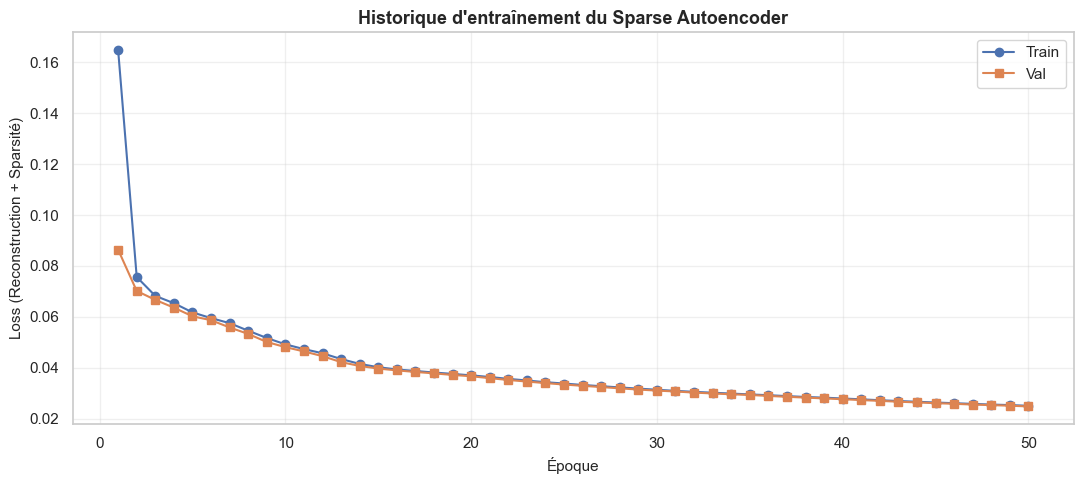

In [10]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
ax.plot(final_history["epoch"], final_history["train_loss"], marker="o", label="Train", linewidth=1.5)
ax.plot(final_history["epoch"], final_history["val_loss"], marker="s", label="Val", linewidth=1.5)
ax.set_xlabel("Époque", fontsize=11)
ax.set_ylabel("Loss (Reconstruction + Sparsité)", fontsize=11)
ax.set_title("Historique d'entraînement du Sparse Autoencoder", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

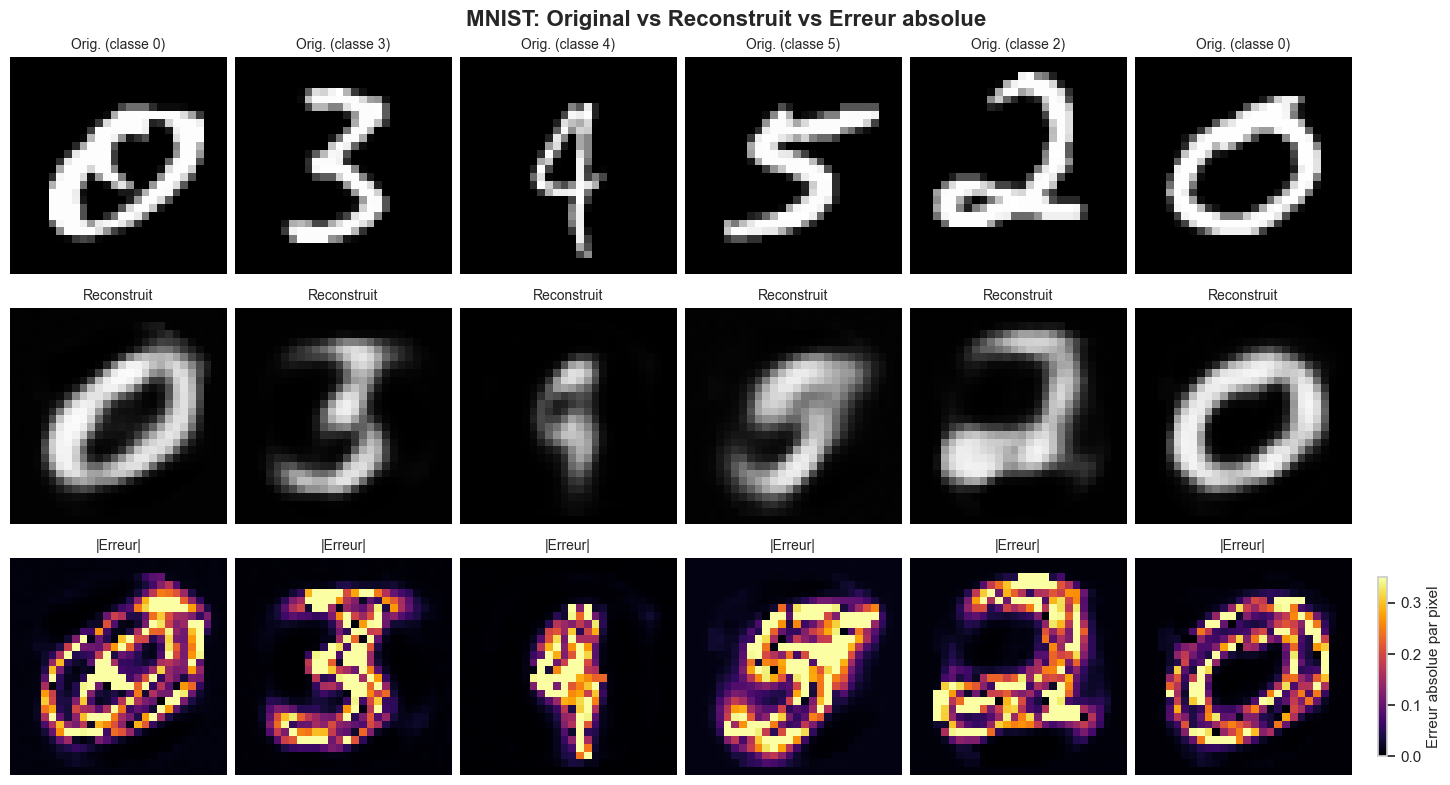

In [11]:
n_show = 6
sample_idx = np.arange(n_show)

fig, axes = plt.subplots(3, n_show, figsize=(2.4 * n_show, 7.8), constrained_layout=True)
fig.suptitle("MNIST: Original vs Reconstruit vs Erreur absolue", fontsize=16, fontweight="bold")

for col, idx in enumerate(sample_idx):
    original_img = X_test[idx].reshape(28, 28)
    recon_img = X_test_recon[idx].reshape(28, 28)
    abs_err = np.abs(original_img - recon_img)

    axes[0, col].imshow(original_img, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"Orig. (classe {y_test[idx]})", fontsize=10)
    axes[0, col].axis("off")

    axes[1, col].imshow(recon_img, cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title("Reconstruit", fontsize=10)
    axes[1, col].axis("off")

    err_im = axes[2, col].imshow(abs_err, cmap="inferno", vmin=0, vmax=0.35)
    axes[2, col].set_title("|Erreur|", fontsize=10)
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Reconstruit", fontsize=11)
axes[2, 0].set_ylabel("Erreur", fontsize=11)

cbar = fig.colorbar(err_im, ax=axes[2, :], shrink=0.78, pad=0.02)
cbar.set_label("Erreur absolue par pixel")

plt.show()

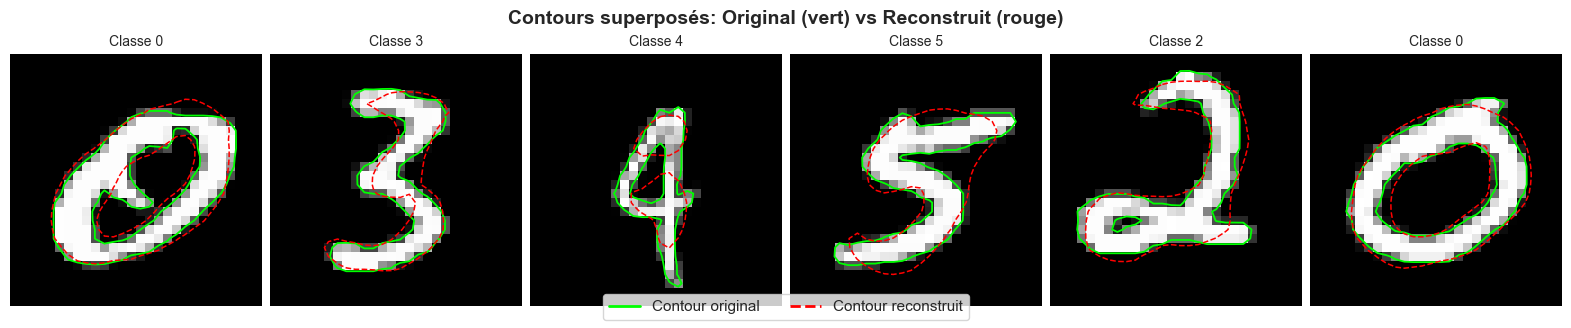

In [12]:
fig2, axes2 = plt.subplots(1, n_show, figsize=(2.6 * n_show, 3.2), constrained_layout=True)
fig2.suptitle("Contours superposés: Original (vert) vs Reconstruit (rouge)", fontsize=14, fontweight="bold")

for col, idx in enumerate(sample_idx):
    original_img = X_test[idx].reshape(28, 28)
    recon_img = X_test_recon[idx].reshape(28, 28)

    axes2[col].imshow(original_img, cmap="gray", vmin=0, vmax=1)
    axes2[col].contour(original_img, levels=[0.35], colors=["lime"], linewidths=1.3)
    axes2[col].contour(recon_img, levels=[0.35], colors=["red"], linewidths=1.1, linestyles="--")
    axes2[col].set_title(f"Classe {y_test[idx]}", fontsize=10)
    axes2[col].axis("off")

legend_handles = [
    Line2D([0], [0], color="lime", linewidth=2, label="Contour original"),
    Line2D([0], [0], color="red", linewidth=2, linestyle="--", label="Contour reconstruit"),
]
fig2.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=True)
plt.show()

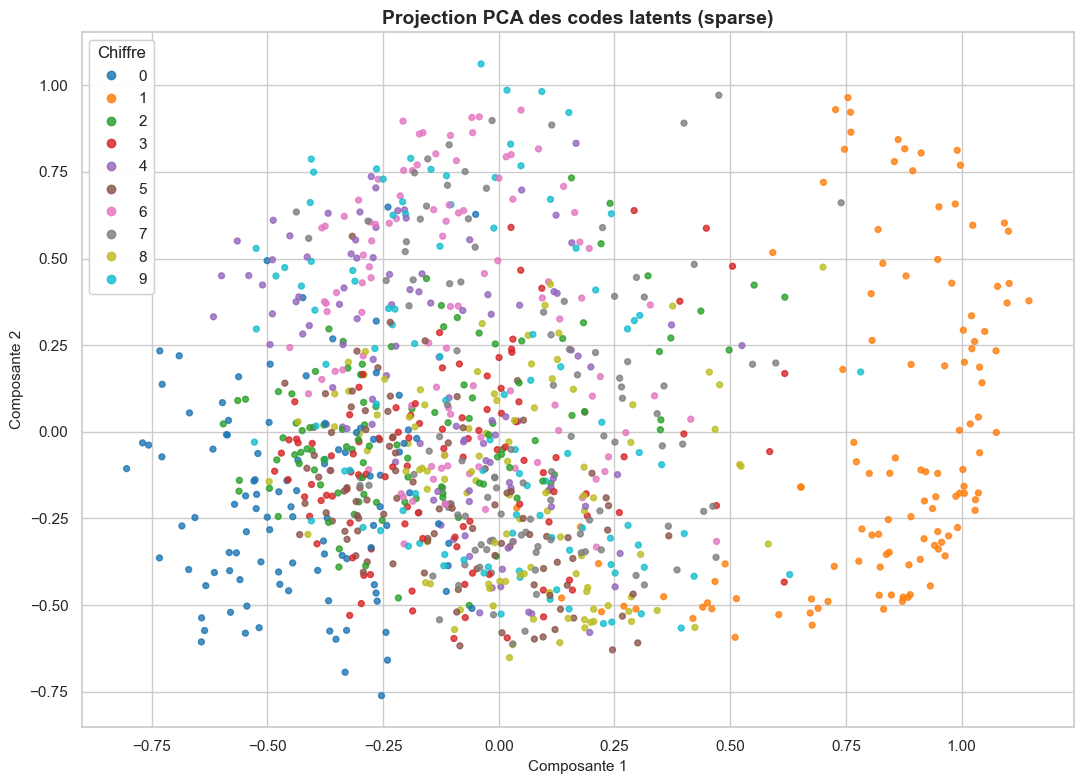

In [13]:
if latent_test.shape[1] > 2:
    latent_vis = PCA(n_components=2, random_state=42).fit_transform(latent_test)
    latent_title = "Projection PCA des codes latents (sparse)"
else:
    latent_vis = latent_test
    latent_title = "Espace latent 2D (sparse)"

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    latent_vis[:, 0],
    latent_vis[:, 1],
    c=y_test,
    cmap="tab10",
    s=18,
    alpha=0.8,
)
ax.set_title(latent_title, fontsize=14, fontweight="bold")
ax.set_xlabel("Composante 1", fontsize=11)
ax.set_ylabel("Composante 2", fontsize=11)
legend = ax.legend(*scatter.legend_elements(), title="Chiffre", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

## Résumé des résultats

In [14]:
summary = pd.DataFrame([
    {"Métrique": "Best Validation Loss", "Valeur": f"{study.best_value:.6f}"},
    {"Métrique": "Test MSE", "Valeur": f"{test_mse:.6f}"},
    {"Métrique": "Test RMSE", "Valeur": f"{test_rmse:.6f}"},
    {"Métrique": "Test MAE", "Valeur": f"{test_mae:.6f}"},
    {"Métrique": "Latent Dimension", "Valeur": best_params["latent_dim"]},
    {"Métrique": "Hidden Dimension", "Valeur": best_params["hidden_dim"]},
    {"Métrique": "Target Sparsity (rho)", "Valeur": f"{best_params['rho']:.4f}"},
    {"Métrique": "Sparsity Beta", "Valeur": f"{best_params['sparsity_beta']:.6f}"},
    {"Métrique": "Learning Rate", "Valeur": f"{best_params['learning_rate']:.6f}"},
    {"Métrique": "Temps entraînement final", "Valeur": f"{trainval_fit_time:.1f}s"},
    {"Métrique": "Compression", "Valeur": f"784 → {best_params['latent_dim']}"},
])
summary

,Métrique,Valeur
0,Best Validation Loss,0.031859
1,Test MSE,0.024728
2,Test RMSE,0.157250
3,Test MAE,0.072769
4,Latent Dimension,32
5,Hidden Dimension,96
6,Target Sparsity (rho),0.1547
7,Sparsity Beta,0.005163
8,Learning Rate,0.000528
9,Temps entraînement final,89.2s
